# 14 練習問題 解答 — FABMOS 確率スイッチ
対象: [`notebooks/14_fabmos.ipynb`](../notebooks/14_fabmos.ipynb)

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, matplotlib.pyplot as plt
from ecell4 import run_simulation
from ecell4_base.core import NetworkModel, ReactionRule, Species
Goff,Gon,P = (Species(x) for x in ['Goff','Gon','P'])
S_PROD=50.0; SP=['Goff','Gon','P']
def R(a,b,k): return ReactionRule(a,b,k)
def build(f, bias=1.0, d_deg=1.0):
    k_off=f; k_on=f*bias; mdl=NetworkModel()
    for x in [R([Goff],[Gon],k_on),R([Gon],[Goff],k_off),R([Gon],[Gon,P],S_PROD),R([P],[],d_deg)]:
        mdl.add_reaction_rule(x)
    return mdl
def population(f, bias=1.0, d_deg=1.0, n=300, t_end=30.0):
    vals=np.empty(n)
    for i in range(n):
        y0={'Goff':1} if i%2==0 else {'Gon':1}
        vals[i]=run_simulation(t_end,y0=y0,model=build(f,bias,d_deg),solver='gillespie',ndiv=1,species_list=SP,rndseed=i).as_array()[-1][3]
    return vals

## Q1. `bias`≠1 にすると平均・分布は? （頻度と bias は独立か）

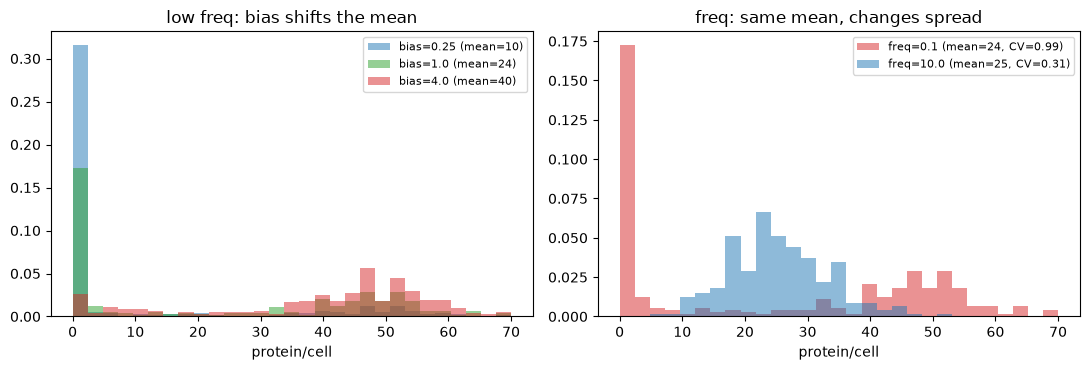

In [2]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(11,3.8)); bins=np.linspace(0,70,30)
# 頻度固定(低=0.1)で bias を変える → 平均が動く
for bias,c in [(0.25,'C0'),(1.0,'C2'),(4.0,'C3')]:
    v=population(0.1,bias=bias,n=300)
    ax1.hist(v,bins=bins,alpha=.5,color=c,density=True,label=f'bias={bias} (mean={v.mean():.0f})')
ax1.set_title('low freq: bias shifts the mean'); ax1.set_xlabel('protein/cell'); ax1.legend(fontsize=8)
# bias 固定(=1)で 頻度を変える → 平均一定・ばらつきだけ動く
for f,c in [(0.1,'C3'),(10.0,'C0')]:
    v=population(f,bias=1.0,n=300)
    ax2.hist(v,bins=bins,alpha=.5,color=c,density=True,label=f'freq={f} (mean={v.mean():.0f}, CV={v.std()/v.mean():.2f})')
ax2.set_title('freq: same mean, changes spread'); ax2.set_xlabel('protein/cell'); ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()

**答**: **bias**（=$k_{on}/k_{off}$）は ON 割合 $\frac{bias}{1+bias}$ を決めるので **平均発現を動かす**（bias=0.25→平均低, 4→高）。**頻度**は平均を変えずに**分布の形（ばらつき）だけ**を動かす。よって bias で平均、頻度でばらつきを **独立に**設計できる——これが FABMOS の核。

## Q2. タンパク質寿命 `D_DEG` を変えると bimodal/unimodal の境目の頻度は?

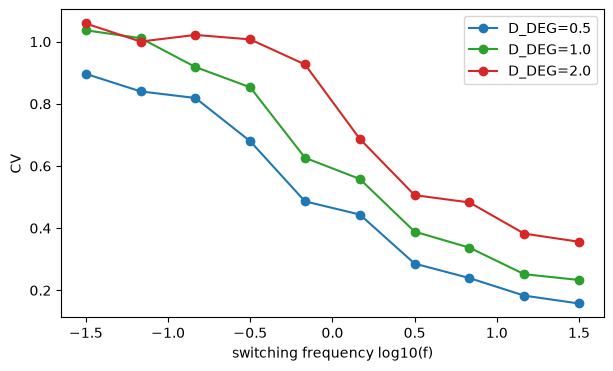

In [3]:
f_grid=np.logspace(-1.5,1.5,10); fig,ax=plt.subplots(figsize=(7,4))
for d_deg,c in [(0.5,'C0'),(1.0,'C2'),(2.0,'C3')]:
    cv=[ (lambda v: v.std()/v.mean())(population(f,d_deg=d_deg,n=200,t_end=30.0/ (d_deg))) for f in f_grid]
    ax.plot(np.log10(f_grid),cv,'o-',color=c,label=f'D_DEG={d_deg}')
ax.set_xlabel('switching frequency log10(f)'); ax.set_ylabel('CV'); ax.legend(); plt.show()

**答**: bimodal↔unimodal の境目は「スイッチ速度 $f$ と タンパク質分解速度 $D_{DEG}$ の比」で決まる。$D_{DEG}$ を上げる（P を短寿命に）と、P が状態変化に速く追随できるので、**より高い頻度まで bimodal が保たれる**＝境目の頻度が高 $f$ 側へ動く。逆に P が長寿命だと低い頻度でも時間平均されて unimodal になりやすい。鍵は $f/D_{DEG}$。

## Q3. 1 細胞の時系列 $P(t)$（低頻度は矩形波的、高頻度は中央で小刻み）

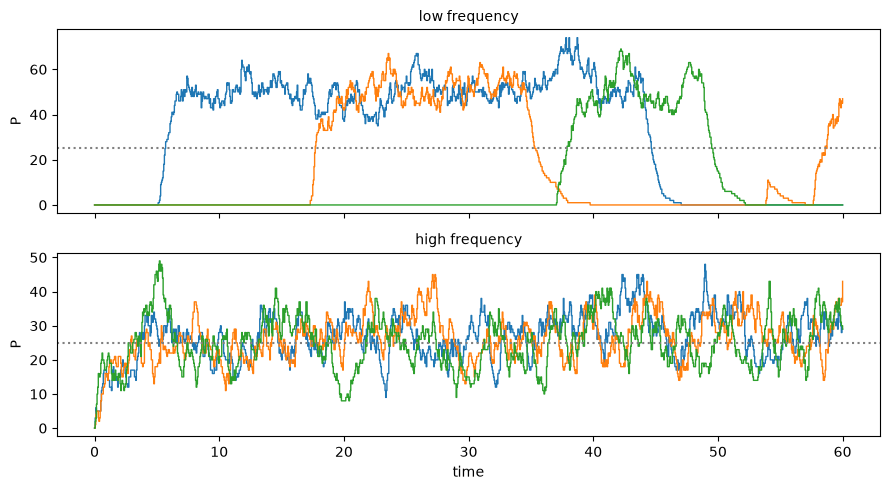

In [4]:
fig,(ax1,ax2)=plt.subplots(2,1,figsize=(9,5),sharex=True)
for ax,f,c,lab in [(ax1,0.1,'C3','low frequency'),(ax2,10.0,'C0','high frequency')]:
    for seed in range(3):
        a=run_simulation(60.0,y0={'Goff':1},model=build(f),solver='gillespie',ndiv=1200,species_list=SP,rndseed=seed).as_array()
        ax.step(a[:,0],a[:,3],where='post',lw=1)
    ax.axhline(25,ls=':',c='gray'); ax.set_ylabel('P'); ax.set_title(lab, fontsize=10)
ax2.set_xlabel('time'); plt.tight_layout(); plt.show()

**答**: **低頻度**では 1 細胞が OFF(0付近)と ON(50付近)に長く留まり、$P(t)$ が **0↔50 を行き来する矩形波的**な軌道になる（時刻を切ると 0 か 50 の二峰＝bimodal）。**高頻度**では状態が速く入れ替わり、$P(t)$ は **中央(~25)を小刻みに揺れる**だけ（切ると中央一峰＝unimodal）。集団分布の bimodal/unimodal が、1 細胞軌道の質的違いから生まれることが見える。

## Q4.（考察）bio-a: sRNA 制御を「スイッチ」と見立てた表現型多様性

**答（考察）**: Hfq/sRNA 回路も細胞間ばらつきを生む（02 の閾値ノイズ）。sRNA 制御を「OFF/ON スイッチ」と見立てると、スイッチの**頻度・bias** に相当するのは sRNA の誘導ダイナミクスや Hfq 競合の状態。オーソログ間で Hfq 依存性（応答の速さ・閾値の鋭さ）が違えば、同じ環境変動でも生じる**表現型多様性（bet-hedging）の度合い**が変わると予測できる。「進化が制御回路のノイズ特性を通じて集団戦略（persister 等）を調整する」という視点で、bio-e の枠を表現型ばらつきへ拡張する候補。